# Structural Damage Recognition using SVM

**Project:** Binary structural damage classification using the PEER Φ-Net Task 2 dataset.

Pipeline: **PEER `.npy` images → labels → resize/grayscale → HOG features → RBF SVM → evaluation**

Labels:
- `0` = Damaged (D)
- `1` = Undamaged (UD)

This notebook is designed for the actual PEER `.npy` files you downloaded. It does **not** require JPG `damaged/undamaged` folders and does not use TensorFlow.


## 1. Imports

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

print("Imports successful.")


Matplotlib is building the font cache; this may take a moment.


Imports successful.


## 2. Dataset paths

In [2]:
# The notebook is inside structural_damage_svm_project/notebooks/
# Therefore ../data points to the project's data folder.

DATA_DIR = pathlib.Path("../data")
TASK1_DIR = DATA_DIR / "task2_damage_state_1"
TASK2_DIR = DATA_DIR / "task2_damage_state_2"
RESULTS_DIR = pathlib.Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "X_train": TASK2_DIR / "task2_X_train.npy",
    "y_train": TASK1_DIR / "task2_y_train.npy",
    "X_test": TASK1_DIR / "task2_X_test.npy",
    "y_test": TASK1_DIR / "task2_y_test.npy",
}

for name, path in FILES.items():
    print(f"{name}: {path} | exists={path.exists()}")

missing = [str(p) for p in FILES.values() if not p.exists()]
if missing:
    raise FileNotFoundError("Missing files:\n" + "\n".join(missing))


X_train: ..\data\task2_damage_state_2\task2_X_train.npy | exists=True
y_train: ..\data\task2_damage_state_1\task2_y_train.npy | exists=True
X_test: ..\data\task2_damage_state_1\task2_X_test.npy | exists=True
y_test: ..\data\task2_damage_state_1\task2_y_test.npy | exists=True


## 3. Load labels and inspect the dataset

In [3]:
# The large image arrays are memory-mapped first, so the entire dataset
# is not unnecessarily copied into RAM.

X_train_raw = np.load(FILES["X_train"], mmap_mode="r")
y_train_raw = np.load(FILES["y_train"])
X_test_raw = np.load(FILES["X_test"], mmap_mode="r")
y_test_raw = np.load(FILES["y_test"])

# PEER labels may be one-hot encoded with shape (N, 2).
y_train = np.argmax(y_train_raw, axis=1) if y_train_raw.ndim == 2 else y_train_raw.astype(int)
y_test = np.argmax(y_test_raw, axis=1) if y_test_raw.ndim == 2 else y_test_raw.astype(int)

print("X_train:", X_train_raw.shape, X_train_raw.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("X_test :", X_test_raw.shape, X_test_raw.dtype)
print("y_test :", y_test.shape, y_test.dtype)

print("\nTraining class counts:")
print("Damaged (0):", np.sum(y_train == 0))
print("Undamaged (1):", np.sum(y_train == 1))

print("\nTest class counts:")
print("Damaged (0):", np.sum(y_test == 0))
print("Undamaged (1):", np.sum(y_test == 1))


X_train: (11811, 224, 224, 3) float32
y_train: (11811,) int64
X_test : (1460, 224, 224, 3) float32
y_test : (1460,) int64

Training class counts:
Damaged (0): 6282
Undamaged (1): 5529

Test class counts:
Damaged (0): 745
Undamaged (1): 715


## 4. Show one example image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-94.939..131.32].


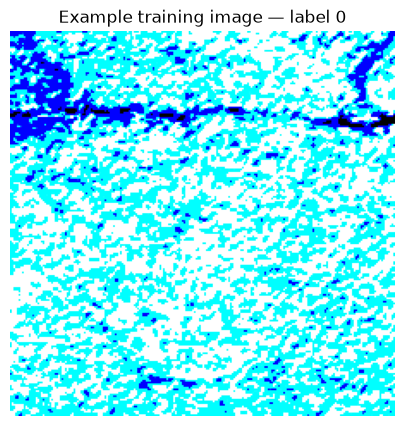

In [4]:
plt.figure(figsize=(5, 5))
plt.imshow(X_train_raw[0])
plt.title(f"Example training image — label {y_train[0]}")
plt.axis("off")
plt.show()


## 5. Build a manageable HOG feature set

To keep the RBF SVM practical on a normal student laptop, images are resized to **64×64 grayscale** before HOG extraction.

The RBF SVM is trained on a stratified subset of up to **6000 training images**. This keeps the kernel computation manageable while still giving the project a substantial training set.


In [5]:
HOG_IMAGE_SIZE = (64, 64)
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)

MAX_SVM_TRAIN = 6000
SEED = 42

def make_hog_features(X, indices):
    features = []

    for i in indices:
        img = np.asarray(X[i])

        if img.dtype != np.uint8:
            img = img.astype(np.float32)
            if img.max() > 1.0:
                img /= 255.0

        gray = np.mean(img, axis=2) if img.ndim == 3 else img
        gray = resize(gray, HOG_IMAGE_SIZE, anti_aliasing=True)

        feat = hog(
            gray,
            orientations=HOG_ORIENTATIONS,
            pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK,
            block_norm="L2-Hys",
            feature_vector=True,
        )
        features.append(feat.astype(np.float32))

    return np.asarray(features, dtype=np.float32)

train_indices = np.arange(len(y_train))

if MAX_SVM_TRAIN is not None and MAX_SVM_TRAIN < len(train_indices):
    train_indices, _ = train_test_split(
        train_indices,
        train_size=MAX_SVM_TRAIN,
        stratify=y_train,
        random_state=SEED,
    )

test_indices = np.arange(len(y_test))

print("Samples used for SVM training:", len(train_indices))
print("Samples used for final testing:", len(test_indices))


Samples used for SVM training: 6000
Samples used for final testing: 1460


## 6. Extract HOG features

In [6]:
print("Extracting training HOG features...")
X_hog_train = make_hog_features(X_train_raw, train_indices)
y_hog_train = y_train[train_indices]

print("Extracting test HOG features...")
X_hog_test = make_hog_features(X_test_raw, test_indices)
y_hog_test = y_test[test_indices]

print("X_hog_train shape:", X_hog_train.shape)
print("X_hog_test shape :", X_hog_test.shape)


Extracting training HOG features...
Extracting test HOG features...
X_hog_train shape: (6000, 1764)
X_hog_test shape : (1460, 1764)


## 7. Scale the HOG features

In [7]:
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_hog_train)
X_scaled_test = scaler.transform(X_hog_test)

joblib.dump(scaler, RESULTS_DIR / "hog_scaler.pkl")

print("Scaling complete.")
print("Scaled training shape:", X_scaled_train.shape)


Scaling complete.
Scaled training shape: (6000, 1764)


## 8. Train the RBF SVM

This is the main machine-learning step.

- Kernel: RBF
- `C = 10`
- `gamma = "scale"`

This step may take several minutes depending on the laptop.


In [8]:
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    cache_size=4096,
)

print("Training SVM...")
svm_model.fit(X_scaled_train, y_hog_train)
print("SVM training complete.")

joblib.dump(svm_model, RESULTS_DIR / "svm_rbf_model.pkl")


Training SVM...
SVM training complete.


['..\\results\\svm_rbf_model.pkl']

## 9. Evaluate the SVM

In [9]:
y_pred = svm_model.predict(X_scaled_test)

accuracy = accuracy_score(y_hog_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")

print("\nClassification Report:")
print(classification_report(
    y_hog_test,
    y_pred,
    target_names=["Damaged", "Undamaged"],
    digits=4,
))


Test Accuracy: 0.6753 (67.53%)

Classification Report:
              precision    recall  f1-score   support

     Damaged     0.6679    0.7235    0.6946       745
   Undamaged     0.6845    0.6252    0.6535       715

    accuracy                         0.6753      1460
   macro avg     0.6762    0.6743    0.6740      1460
weighted avg     0.6760    0.6753    0.6745      1460



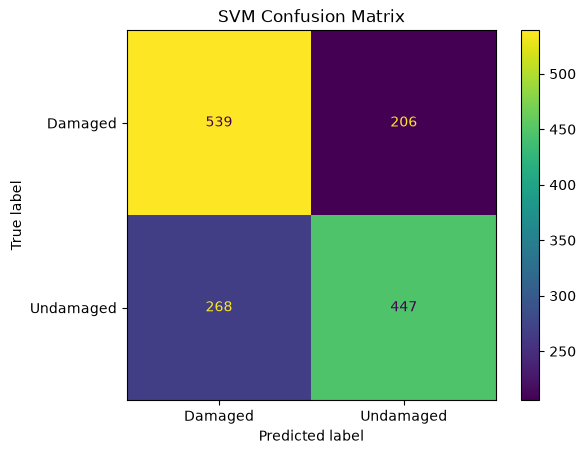

Results saved in: C:\Users\Bharath\Downloads\structural_damage_svm_project\results


In [10]:
cm = confusion_matrix(y_hog_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Damaged", "Undamaged"],
)
disp.plot(values_format="d")
plt.title("SVM Confusion Matrix")
plt.show()

np.save(RESULTS_DIR / "X_train_hog.npy", X_hog_train)
np.save(RESULTS_DIR / "X_test_hog.npy", X_hog_test)
np.save(RESULTS_DIR / "y_train_used.npy", y_hog_train)
np.save(RESULTS_DIR / "y_test.npy", y_hog_test)

with open(RESULTS_DIR / "metrics.txt", "w", encoding="utf-8") as f:
    f.write(f"Test accuracy: {accuracy:.6f}\n")
    f.write("\nClassification report:\n")
    f.write(classification_report(
        y_hog_test,
        y_pred,
        target_names=["Damaged", "Undamaged"],
        digits=4,
    ))

print("Results saved in:", RESULTS_DIR.resolve())


## 10. Project conclusion

The trained RBF SVM classifies structural images into **Damaged** and **Undamaged** classes using HOG image features.

For the report, record the **actual Test Accuracy, precision, recall, F1-score, and confusion matrix produced by the run**. Do not invent an accuracy before running the model.
